In [4]:
import numpy as np
import sys
import os
import warnings
warnings.filterwarnings('ignore')

project_path = os.path.abspath("Developer/data-shapley")
if project_path not in sys.path:
    sys.path.append(project_path)

from classes.logistic_regression import LogisticRegression
from classes.data_loader import DataLoader
from classes.graph import Graph
from classes.experiment import Experiment

graph = Graph()
loader = DataLoader()
experiment = Experiment()

Total train samples: 721


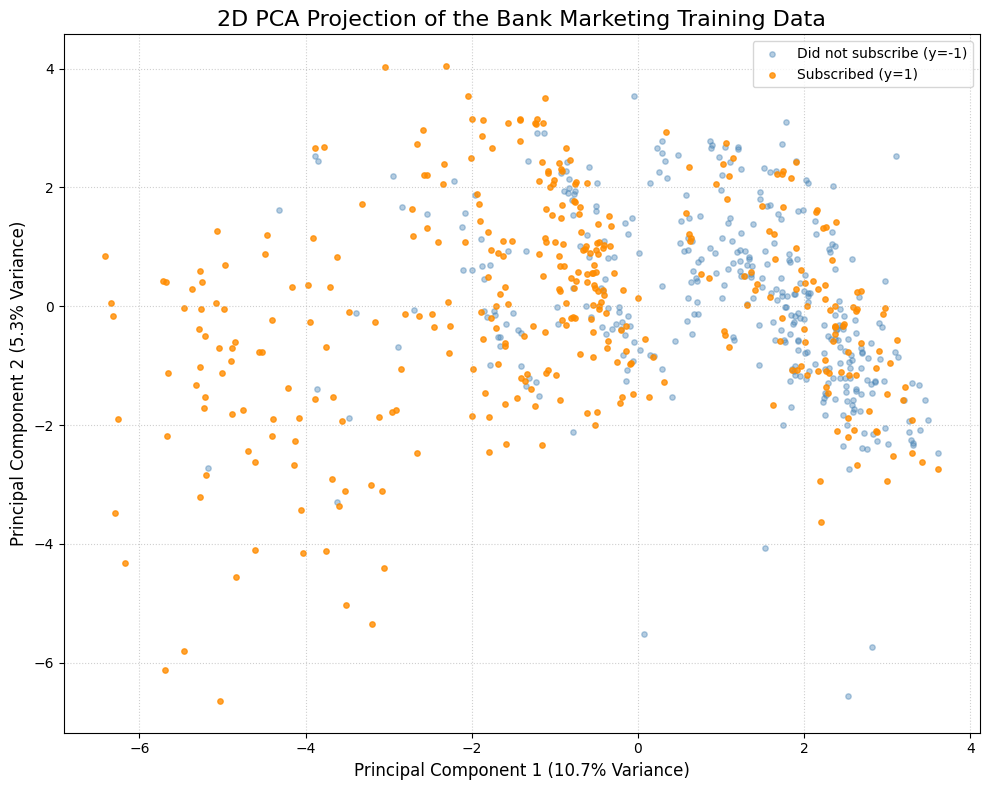

In [5]:
# Data Preprocessing & Loading
X_train, y_train, X_test, y_test, X_raw, y_raw = loader.load_bank_dataset('/Users/carlofalchi/Developer/data-shapley/dataset/bank-additional.csv')
print(f"Total train samples: {len(y_train)}")
graph.bank_projection(X_train, y_train)

Total train samples: 1000
Number of noisy labels injected: 350


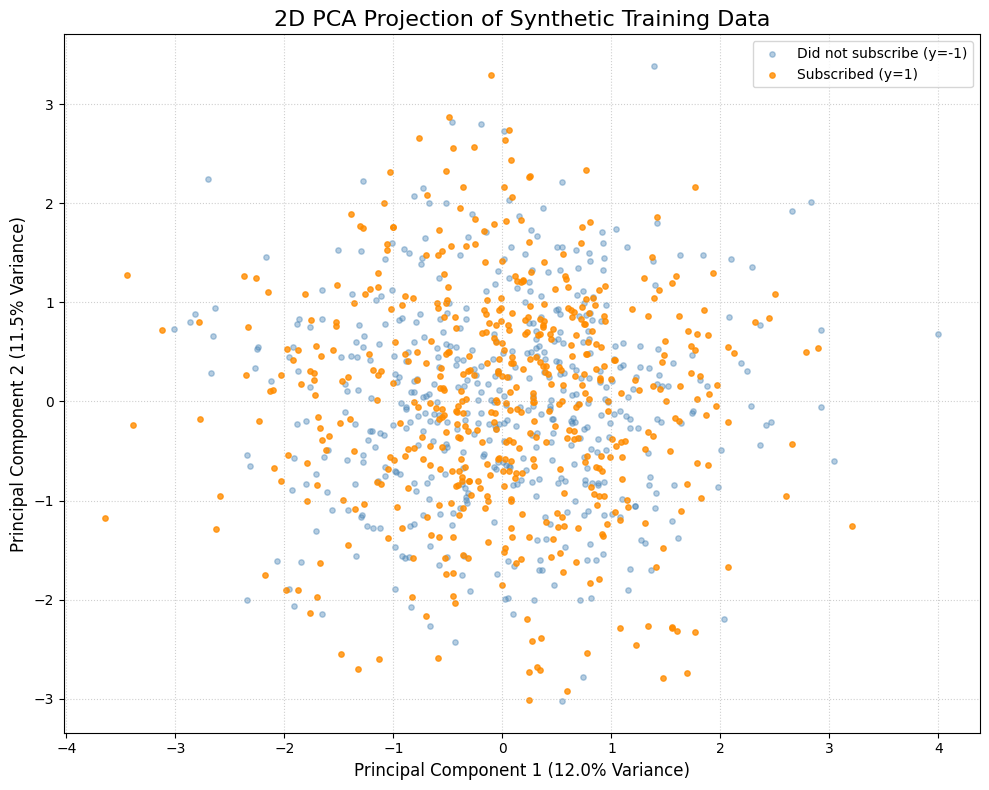

In [6]:

X_train_synt, y_train_synt, y_true_synt, bad_data_indices, X_test_synt, y_test_synt  = loader.generate_synthetic_dataset(
    n_samples=1000, 
    n_test=200,
    n_features=10, 
    noise_ratio=0.35
)

print(f"Total train samples: {len(y_train_synt)}")
print(f"Number of noisy labels injected: {len(bad_data_indices)}")
graph.synthetic_projection(X_train_synt, y_train_synt)

In [7]:
# Train the model on the Real (sampled) Dataset
model = LogisticRegression(learning_rate=0.1, epochs=1000)
model.train(X_train, y_train)
print(f"Model Training completed! - Real Data")
# Evaluate
predictions = model.predict(X_test)
accuracy = np.mean(predictions == y_test)
print(f"Model Test Accuracy: {accuracy * 100:.2f}% ")

# Train the model on synthetic data
model = LogisticRegression(learning_rate=0.1, epochs=1000)
model.train(X_train_synt, y_train_synt)
print(f"Model Training completed! - Synthetic Data (with Noise)")
# Evaluate
predictions = model.predict(X_test_synt)
accuracy_synt = np.mean(predictions == y_test_synt)
print(f"Model Test Accuracy: {accuracy_synt * 100:.2f}%")

Model Training completed! - Real Data
Model Test Accuracy: 85.64% 
Model Training completed! - Synthetic Data (with Noise)
Model Test Accuracy: 88.50%


Starting TMC-Shapley valuation...
Baseline Score (Empty): -0.9973
Full Dataset Score (All Data): -0.5264
Completed 10 iterations... Shapley value average: 0.00064117,stability=0.002145
Completed 20 iterations... Shapley value average: 0.00064323,stability=0.000957
Completed 30 iterations... Shapley value average: 0.00064338,stability=0.000571
Completed 40 iterations... Shapley value average: 0.00064317,stability=0.000484
Completed 50 iterations... Shapley value average: 0.00064294,stability=0.000337
Completed 60 iterations... Shapley value average: 0.00064295,stability=0.000247
Completed 70 iterations... Shapley value average: 0.00064296,stability=0.000203
Completed 80 iterations... Shapley value average: 0.00064333,stability=0.000173
Completed 90 iterations... Shapley value average: 0.00064313,stability=0.000164
Completed 100 iterations... Shapley value average: 0.00064318,stability=0.000162
Completed 110 iterations... Shapley value average: 0.00064298,stability=0.000147
Completed 120

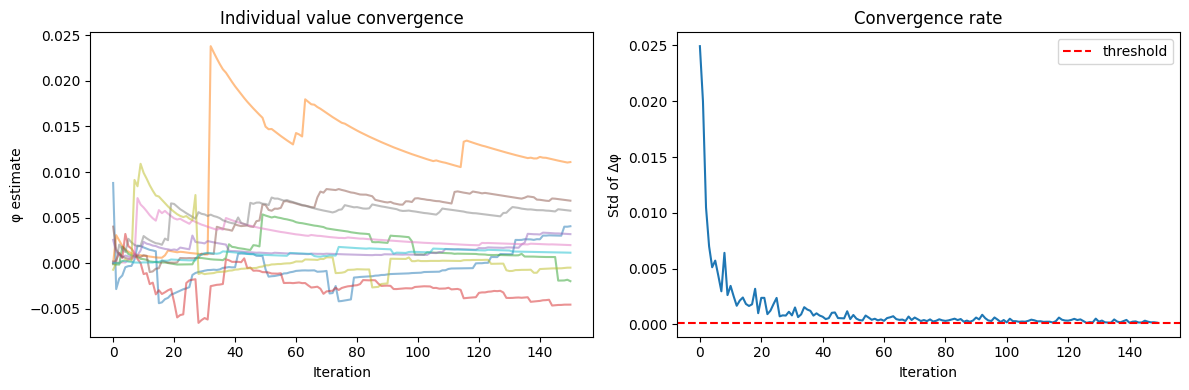

In [8]:
# Train the model and calculate shapley values for Real Dataset
model = LogisticRegression(learning_rate=0.1, epochs=1000)
print("Starting TMC-Shapley valuation...")
shapley_values, phi_history = model.tmc_shapley(
        X_train, 
        y_train, 
        X_test, 
        y_test, 
        tolerance=0.010
    )
average_shapley = np.mean(shapley_values)
print(f"Average Value {average_shapley:.8f}")

# Train the model and calculate shapley values for Synthetic Dataset
model = LogisticRegression(learning_rate=0.1, epochs=1000)
print("Starting TMC-Shapley valuation for synthetic data...")
shapley_values_synt, phi_history_synth = model.tmc_shapley(
        X_train_synt, 
        y_train_synt, 
        X_test_synt, 
        y_test_synt, 
        tolerance=0.010
    )
average_shapley_synt = np.mean(shapley_values_synt)
print(f"Average Value {average_shapley_synt:.8f}")

graph.convergence(shapley_values, phi_history)

In [9]:
print("\n## REAL DATA ##")
least_valuable_indices = np.argsort(shapley_values)
most_valuable_indices = np.argsort(shapley_values)[::-1]
print("--- Top 5 MOST Valuable Data Points ---")
for rank, idx in enumerate(most_valuable_indices[:5]):
    print(f"Rank {rank + 1}: Index {idx} | Shapley Value = {shapley_values[idx]:.6f}")

print("\n--- Top 5 LEAST Valuable Data Points ---")
for rank, idx in enumerate(least_valuable_indices[:5]):
    print(f"Rank {rank + 1}: Index {idx} | Shapley Value = {shapley_values[idx]:.6f}")

print("\n## SYNTHETIC DATA ##")
least_valuable_indices_synt = np.argsort(shapley_values_synt)
most_valuable_indices_synt = np.argsort(shapley_values_synt)[::-1]
print("--- Top 5 MOST Valuable Data Points ---")
for rank, idx in enumerate(most_valuable_indices_synt[:5]):
    print(f"Rank {rank + 1}: Index {idx} | Shapley Value = {shapley_values_synt[idx]:.6f}")

print("\n--- Top 5 LEAST Valuable Data Points ---")
for rank, idx in enumerate(least_valuable_indices_synt[:5]):
    print(f"Rank {rank + 1}: Index {idx} | Shapley Value = {shapley_values_synt[idx]:.6f}")



## REAL DATA ##
--- Top 5 MOST Valuable Data Points ---
Rank 1: Index 40 | Shapley Value = 0.022791
Rank 2: Index 117 | Shapley Value = 0.022571
Rank 3: Index 176 | Shapley Value = 0.017881
Rank 4: Index 248 | Shapley Value = 0.016211
Rank 5: Index 8 | Shapley Value = 0.015610

--- Top 5 LEAST Valuable Data Points ---
Rank 1: Index 609 | Shapley Value = -0.045209
Rank 2: Index 447 | Shapley Value = -0.037279
Rank 3: Index 381 | Shapley Value = -0.028072
Rank 4: Index 58 | Shapley Value = -0.027845
Rank 5: Index 125 | Shapley Value = -0.027730

## SYNTHETIC DATA ##
--- Top 5 MOST Valuable Data Points ---
Rank 1: Index 718 | Shapley Value = 0.027903
Rank 2: Index 539 | Shapley Value = 0.026744
Rank 3: Index 145 | Shapley Value = 0.025864
Rank 4: Index 120 | Shapley Value = 0.025138
Rank 5: Index 792 | Shapley Value = 0.024932

--- Top 5 LEAST Valuable Data Points ---
Rank 1: Index 516 | Shapley Value = -0.051969
Rank 2: Index 636 | Shapley Value = -0.049419
Rank 3: Index 29 | Shapley Va

In [10]:
print(f"-- Real Dataset --")
model = LogisticRegression(learning_rate=0.1, epochs=1000)
accuracy_fractional  = experiment.fractional_remove(model, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, shapley_values=shapley_values, fractional_range=20)

print(f"-- Synthetic Dataset --")
accuracy_fractional_synth  = experiment.fractional_remove(model, X_train=X_train_synt, y_train=y_train_synt, X_test=X_test_synt, y_test=y_test_synt, shapley_values=shapley_values_synt, sorted_desc=True, fractional_range=20)

    

-- Real Dataset --
Model Fractional Removed:0.00 Test Accuracy: 85.64%
Model Fractional Removed:0.02 Test Accuracy: 85.08%
Model Fractional Removed:0.04 Test Accuracy: 86.19%
Model Fractional Removed:0.06 Test Accuracy: 87.85%
Model Fractional Removed:0.08 Test Accuracy: 88.95%
Model Fractional Removed:0.10 Test Accuracy: 89.50%
Model Fractional Removed:0.12 Test Accuracy: 89.50%
Model Fractional Removed:0.14 Test Accuracy: 90.61%
Model Fractional Removed:0.16 Test Accuracy: 89.50%
Model Fractional Removed:0.18 Test Accuracy: 88.40%
-- Synthetic Dataset --
Model Fractional Removed:0.00 Test Accuracy: 88.50%
Model Fractional Removed:0.02 Test Accuracy: 87.50%
Model Fractional Removed:0.04 Test Accuracy: 82.50%
Model Fractional Removed:0.06 Test Accuracy: 78.50%
Model Fractional Removed:0.08 Test Accuracy: 77.00%
Model Fractional Removed:0.10 Test Accuracy: 70.50%
Model Fractional Removed:0.12 Test Accuracy: 64.50%
Model Fractional Removed:0.14 Test Accuracy: 59.50%
Model Fractional Remo

In [11]:
print(f"-- Real Dataset --")
model = LogisticRegression(learning_rate=0.1, epochs=1000)
accuracy_random = experiment.random_remove(model, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, fractional_range=20)

print(f"-- Synthetic Dataset --")
model = LogisticRegression(learning_rate=0.1, epochs=1000)
accuracy_random_synt = experiment.random_remove(model, X_train=X_train_synt, y_train=y_train_synt, X_test=X_test_synt, y_test=y_test_synt, fractional_range=20)


-- Real Dataset --
Model Random Removed:0.00 Test Accuracy: 85.64%
Model Random Removed:0.02 Test Accuracy: 86.19%
Model Random Removed:0.04 Test Accuracy: 83.98%
Model Random Removed:0.06 Test Accuracy: 85.08%
Model Random Removed:0.08 Test Accuracy: 86.19%
Model Random Removed:0.10 Test Accuracy: 84.53%
Model Random Removed:0.12 Test Accuracy: 85.64%
Model Random Removed:0.14 Test Accuracy: 83.43%
Model Random Removed:0.16 Test Accuracy: 83.98%
Model Random Removed:0.18 Test Accuracy: 85.08%
-- Synthetic Dataset --
Model Random Removed:0.00 Test Accuracy: 88.50%
Model Random Removed:0.02 Test Accuracy: 88.00%
Model Random Removed:0.04 Test Accuracy: 88.00%
Model Random Removed:0.06 Test Accuracy: 84.50%
Model Random Removed:0.08 Test Accuracy: 88.00%
Model Random Removed:0.10 Test Accuracy: 89.00%
Model Random Removed:0.12 Test Accuracy: 85.00%
Model Random Removed:0.14 Test Accuracy: 87.50%
Model Random Removed:0.16 Test Accuracy: 82.50%
Model Random Removed:0.18 Test Accuracy: 87.5

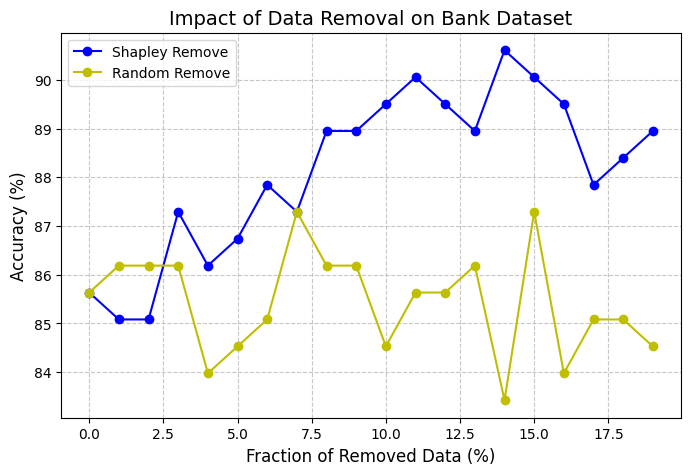

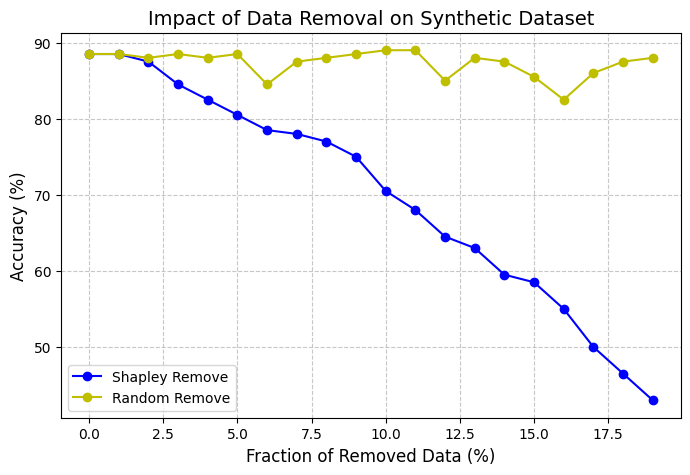

In [12]:
graph.remove(accuracy_fractional, accuracy_random, title = 'Impact of Data Removal on Bank Dataset')
graph.remove(accuracy_fractional_synth, accuracy_random_synt , title = 'Impact of Data Removal on Synthetic Dataset')

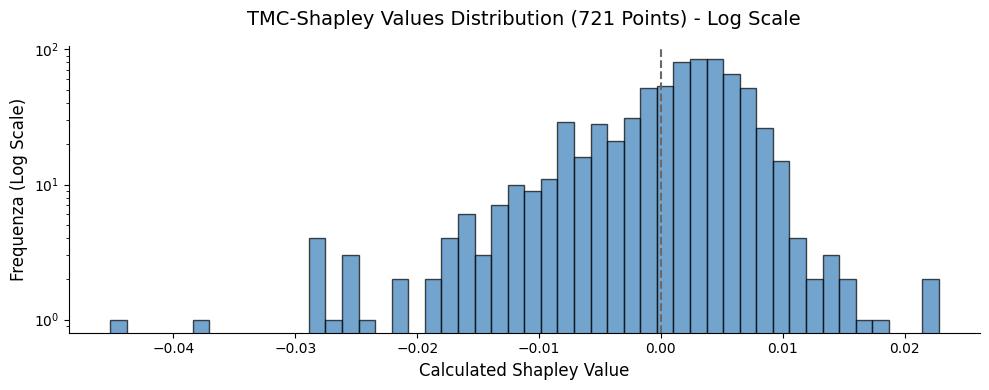

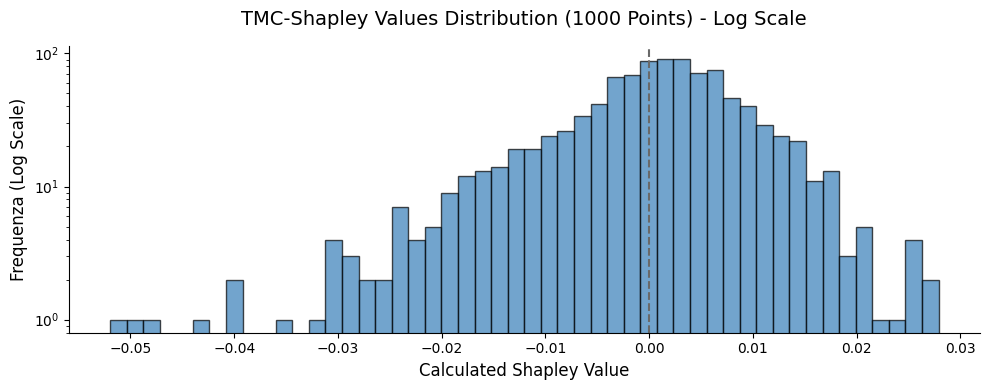

In [21]:
import matplotlib.pyplot as plt

graph.plot_histogram_log(shapley_values)
graph.plot_histogram_log(shapley_values_synt)

In [14]:
model = LogisticRegression(learning_rate=0.1, epochs=1000)
y_train_noisy, _ = experiment.flipping_robustness(y_train=y_train, corruption_rate=0.2)
print("Starting TMC-Shapley valuation with noisy labels...")
shapley_noisy_values, _ = model.tmc_shapley(
        X_train, 
        y_train_noisy, 
        X_test, 
        y_test, 
        tolerance=0.004
    )
average_shapley = np.mean(shapley_noisy_values)
print(f"Average Value with Noisy {average_shapley:.8f}")

--- Starting Label-Flipping Robustness Evaluation ---
Starting TMC-Shapley valuation with noisy labels...
Baseline Score (Empty): -0.9973
Full Dataset Score (All Data): -0.6503
Completed 10 iterations... Shapley value average: 0.00047867,stability=0.003473
Completed 20 iterations... Shapley value average: 0.00047908,stability=0.001744
Completed 30 iterations... Shapley value average: 0.00047930,stability=0.001115
Completed 40 iterations... Shapley value average: 0.00047876,stability=0.000789
Completed 50 iterations... Shapley value average: 0.00047848,stability=0.000679
Completed 60 iterations... Shapley value average: 0.00047828,stability=0.000575
Completed 70 iterations... Shapley value average: 0.00047824,stability=0.000481
Completed 80 iterations... Shapley value average: 0.00047829,stability=0.000351
Completed 90 iterations... Shapley value average: 0.00047836,stability=0.000358
Completed 100 iterations... Shapley value average: 0.00047823,stability=0.000303
Completed 110 iteratio

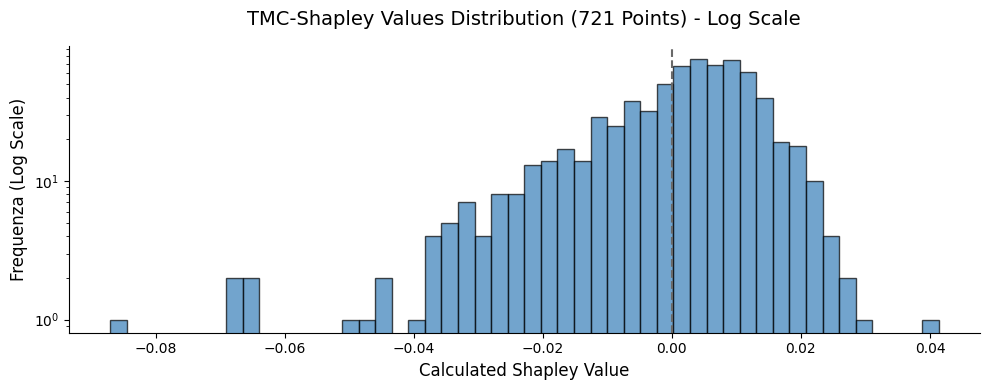

In [20]:
graph.plot_histogram_log(shapley_noisy_values) # 0.20 Noise level

In [16]:
average_shapley = np.mean(shapley_values)
print(f"Average Value {average_shapley:.8f}")

average_shapley = np.mean(shapley_noisy_values)
print(f"Average Value with Noisy {average_shapley:.8f}")


Average Value 0.00064291
Average Value with Noisy 0.00047836


Model Fractional Removed:0.00 Test Accuracy: 79.56%
Model Fractional Removed:0.02 Test Accuracy: 81.77%
Model Fractional Removed:0.04 Test Accuracy: 85.64%
Model Fractional Removed:0.06 Test Accuracy: 88.95%
Model Fractional Removed:0.08 Test Accuracy: 87.85%
Model Fractional Removed:0.10 Test Accuracy: 87.85%
Model Fractional Removed:0.12 Test Accuracy: 86.74%
Model Fractional Removed:0.14 Test Accuracy: 86.19%
Model Fractional Removed:0.16 Test Accuracy: 87.85%
Model Fractional Removed:0.18 Test Accuracy: 89.50%
Model Random Removed:0.00 Test Accuracy: 79.56%
Model Random Removed:0.02 Test Accuracy: 78.45%
Model Random Removed:0.04 Test Accuracy: 79.56%
Model Random Removed:0.06 Test Accuracy: 78.45%
Model Random Removed:0.08 Test Accuracy: 79.01%
Model Random Removed:0.10 Test Accuracy: 80.11%
Model Random Removed:0.12 Test Accuracy: 80.66%
Model Random Removed:0.14 Test Accuracy: 79.56%
Model Random Removed:0.16 Test Accuracy: 81.22%
Model Random Removed:0.18 Test Accuracy: 77.35%


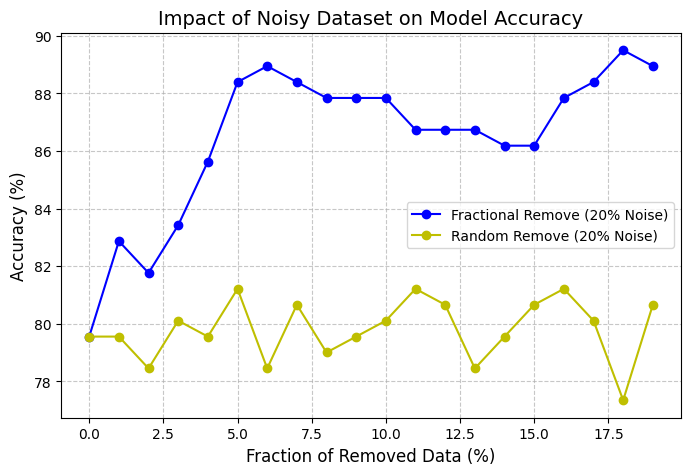

In [17]:
# Fractional remove with noisy labels
model = LogisticRegression(learning_rate=0.1, epochs=1000)
accuracy_noisy_fractional = experiment.fractional_remove(model, X_train=X_train, y_train=y_train_noisy, X_test=X_test, y_test=y_test, shapley_values=shapley_noisy_values, fractional_range=20)
accuracy_noisy_random = experiment.random_remove(model, X_train=X_train, y_train=y_train_noisy, X_test=X_test, y_test=y_test , fractional_range=20)
graph.noisy_data_removal(accuracy_noisy_fractional, accuracy_noisy_random)

In [18]:
model = LogisticRegression(learning_rate=0.1, epochs=1000)
inspection_curves = experiment.robustness(model, X_train, y_train, X_test, y_test)

--- Starting Label-Flipping Robustness Evaluation ---

Starting TMC-Shapley valuation with noisy labels corrupted percentage of 5%...
Baseline Score (Empty): -0.9973
Full Dataset Score (All Data): -0.5199
Completed 10 iterations... Shapley value average: 0.00065801,stability=0.002213
Completed 20 iterations... Shapley value average: 0.00065831,stability=0.001166
Completed 30 iterations... Shapley value average: 0.00065815,stability=0.000821
Completed 40 iterations... Shapley value average: 0.00065866,stability=0.000537
Completed 50 iterations... Shapley value average: 0.00065857,stability=0.000452
Completed 60 iterations... Shapley value average: 0.00065853,stability=0.000345
Completed 70 iterations... Shapley value average: 0.00065848,stability=0.000338
Completed 80 iterations... Shapley value average: 0.00065847,stability=0.000262
Completed 90 iterations... Shapley value average: 0.00065835,stability=0.000208
Completed 100 iterations... Shapley value average: 0.00065835,stability=0.0

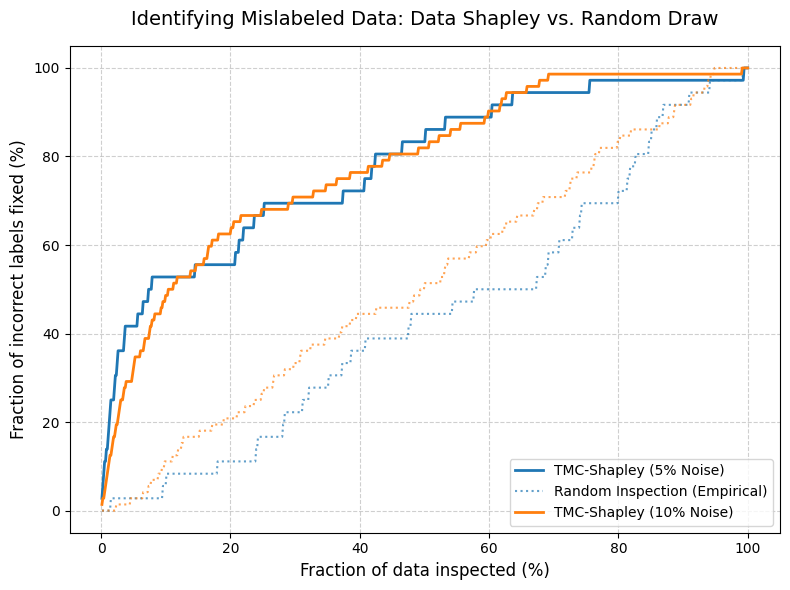

In [19]:
graph.inspection_curves(inspection_curves)